# Live Demo — Variable Construction & Descriptives (v3)
### Session 6 · ExInt II · WU Vienna · SS 2026

**Updated research design:**
- **Y:** RoA = `ib / at`
- **X:** R&D intensity = `xrd / at` (0 if missing)
- **Moderator:** Firm size = `log(at)`
- **H1:** R&D intensity positively affects RoA
- **H2:** Firm size positively moderates the R&D–RoA relationship

> Reference: https://github.com/vkiefner/sme-intl

---
## Cell 1 — Setup & load

In [1]:
import os, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def find_env():
    current = Path(os.getcwd())
    for path in [current] + list(current.parents):
        if (path / '.env').exists(): return path / '.env'
        try:
            for s in path.iterdir():
                if s.is_dir() and (s / '.env').exists(): return s / '.env'
        except PermissionError: continue
    raise FileNotFoundError('Could not find .env')

project_root = find_env().parent
os.chdir(project_root)
print(f'Working directory: {os.getcwd()}')

sns.set_theme(style='whitegrid')
WU_BLUE = '#002f5f'
WU_RED  = '#c8102e'

df = pd.read_parquet('data/processed/panel_clean.parquet')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Working directory: /Users/thomasmacbookair/Documents/medtech-internationalization-drivers
Loaded: 3,108 rows x 447 columns


---
## Cell 2 — Data quality filters + SME filter

In [2]:
print(f'Starting: {len(df):,} rows')

# Data quality: require positive assets, positive sales, positive equity
df = df[(df['at'] > 0.1) & (df['sale'] > 0) & (df['seq'] > 0)].copy()
print(f'After quality filters (at>0.1, sale>0, seq>0): {len(df):,}')

# EU SME: < 250 employees OR assets <= EUR 43m
sme_mask = (df['emp'] < 0.25) | (df['at'] <= 43)
df = df[sme_mask].copy()
print(f'After SME filter: {len(df):,}')

print(f'\nTop countries:')
print(df['loc'].value_counts().head(8).to_string())

Starting: 3,108 rows
After quality filters (at>0.1, sale>0, seq>0): 2,780
After SME filter: 1,196

Top countries:
loc
SWE    372
AUS    193
ISR    109
FRA    107
GBR     80
POL     58
TWN     39
JPN     29


---
## Cell 3 — Variable construction

In [3]:
# ── DEPENDENT VARIABLE ────────────────────────────────────────────────────────
# RoA = ib / at
df['roa'] = df['ib'] / df['at']

# ── INDEPENDENT VARIABLE ──────────────────────────────────────────────────────
# R&D intensity = xrd / at  (missing xrd -> firm did not report -> 0)
df['rd_intensity'] = df['xrd'].fillna(0) / df['at']

# ── MODERATOR ─────────────────────────────────────────────────────────────────
# Firm size = log(at)
df['ln_at'] = df['at'].apply(lambda x: math.log(x) if x > 0 else np.nan)

# H2 interaction: R&D intensity x Firm size
df['rd_x_size'] = df['rd_intensity'] * df['ln_at']

# ── CONTROLS ──────────────────────────────────────────────────────────────────
df['leverage']       = df['dltt'].fillna(0) / df['at']
df['capx_intensity'] = df['capx'].fillna(0) / df['at']
df['cash_ratio']     = df['che'].fillna(0)  / df['at']

# ── COVERAGE ──────────────────────────────────────────────────────────────────
research_vars = ['roa','rd_intensity','ln_at','rd_x_size',
                 'leverage','capx_intensity','cash_ratio']
print('Variable coverage:')
for v in research_vars:
    n   = df[v].notna().sum()
    nz  = (df[v].notna() & (df[v] != 0)).sum()
    pct = n / len(df) * 100
    print(f'  {v:<20}  {n:>7,}  ({pct:>5.1f}%)  non-zero: {nz:>7,}')

Variable coverage:
  roa                     1,196  (100.0%)  non-zero:   1,195
  rd_intensity            1,196  (100.0%)  non-zero:     900
  ln_at                   1,196  (100.0%)  non-zero:   1,196
  rd_x_size               1,196  (100.0%)  non-zero:     900
  leverage                1,196  (100.0%)  non-zero:     763
  capx_intensity          1,196  (100.0%)  non-zero:     993
  cash_ratio              1,196  (100.0%)  non-zero:   1,191


---
## Cell 4 — Drop missing core variables

In [4]:
CORE_VARS = ['roa', 'rd_intensity', 'ln_at', 'leverage']
n_before = len(df)
df = df.dropna(subset=CORE_VARS).copy()
print(f'Dropped {n_before - len(df):,} rows with missing core variables')
print(f'Working sample: {len(df):,} firm-years | {df["gvkey"].nunique():,} firms')

Dropped 0 rows with missing core variables
Working sample: 1,196 firm-years | 207 firms


---
## Cell 5 — Winsorize at 1%-99%

Winsorize ranges (1%-99%):
  roa                   [ -2.2176,    0.2660]
  rd_intensity          [  0.0000,    0.6928]
  leverage              [  0.0000,    0.5902]
  capx_intensity        [  0.0000,    0.3113]
  cash_ratio            [  0.0011,    0.9491]


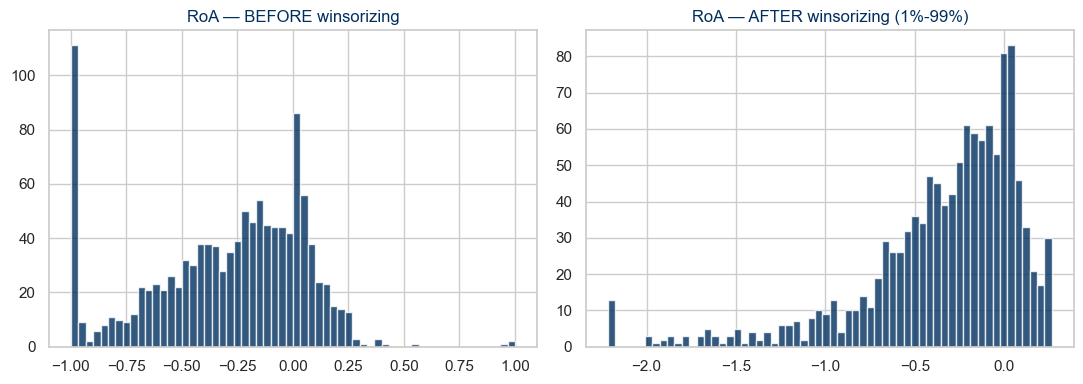

Sample: 1,196 rows


In [5]:
def winsorize(series, lower=0.01, upper=0.99):
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lo, hi)

roa_raw = df['roa'].copy()

WINSORIZE_VARS = ['roa', 'rd_intensity', 'leverage', 'capx_intensity', 'cash_ratio']
print('Winsorize ranges (1%-99%):')
for col in WINSORIZE_VARS:
    df[col] = winsorize(df[col])
    print(f'  {col:<20}  [{df[col].min():>8.4f},  {df[col].max():>8.4f}]')

# Recompute interaction after winsorizing inputs
df['rd_x_size'] = df['rd_intensity'] * df['ln_at']

# Before/after plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(roa_raw.clip(-1, 1), bins=60, color=WU_BLUE, alpha=0.8)
axes[0].set_title('RoA — BEFORE winsorizing', color=WU_BLUE)
axes[1].hist(df['roa'], bins=60, color=WU_BLUE, alpha=0.8)
axes[1].set_title('RoA — AFTER winsorizing (1%-99%)', color=WU_BLUE)
fig.tight_layout()
plt.show()
print(f'Sample: {len(df):,} rows')

---
## Cell 6 — Minimum 3 observations per firm

In [6]:
obs   = df.groupby('gvkey')['fyear'].count()
valid = obs[obs >= 3].index
n_before = len(df)
df = df[df['gvkey'].isin(valid)].copy()
print(f'Min 3 obs: {n_before:,} -> {len(df):,}')
print(f'Final: {len(df):,} firm-years | {df["gvkey"].nunique():,} firms')
print(f'Years: {df["fyear"].min()} - {df["fyear"].max()}')
print(f'R&D firms (rd>0): {(df["rd_intensity"]>0).sum():,} ({(df["rd_intensity"]>0).mean()*100:.1f}%)')

Min 3 obs: 1,196 -> 1,134
Final: 1,134 firm-years | 166 firms
Years: 2015 - 2025
R&D firms (rd>0): 855 (75.4%)


---
## Cell 7 — Summary statistics

What to check:
- **RoA**: mean vs median gap — negative mean, positive median = loss-makers drag mean down
- **R&D intensity**: median = 0 — expected, most SMEs don't report R&D separately
- **Firm size**: log scale — check range is sensible
- **Leverage / CAPX / Cash**: all ratios, should be between 0 and 1

In [7]:
VAR_LABELS = {
    'roa':            'RoA (ib/at)',
    'rd_intensity':   'R&D Intensity (xrd/at)',
    'ln_at':          'Firm Size (log assets)',
    'leverage':       'Leverage (dltt/at)',
    'capx_intensity': 'CAPX Intensity (capx/at)',
    'cash_ratio':     'Cash Ratio (che/at)',
}

summary = (
    df[list(VAR_LABELS.keys())]
    .rename(columns=VAR_LABELS)
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T[['count','mean','std','min','25%','50%','75%','max']]
    .round(4)
)
summary

,count,mean,std,min,25%,50%,75%,max
RoA (ib/at),1134.0,-0.338241,0.448996,-2.217629,-0.517236,-0.22557,-0.013905,0.266027
R&D Intensity (xrd/at),1134.0,0.09798,0.134003,0.0,0.00017,0.048966,0.134873,0.692832
Firm Size (log assets),1134.0,3.599678,1.680738,-1.120858,2.506985,3.387761,4.337665,10.819758
Leverage (dltt/at),1134.0,0.075597,0.122082,0.0,0.0,0.013654,0.101393,0.590199
CAPX Intensity (capx/at),1134.0,0.02766,0.05205,0.0,0.001312,0.008494,0.026478,0.311254
Cash Ratio (che/at),1134.0,0.351844,0.263193,0.001104,0.127003,0.299031,0.538574,0.949066


---
## Cell 8 — Correlation matrix

Check:
- **R&D vs RoA**: expected negative (loss-making firms invest in R&D) or positive?
- **R&D vs size**: do larger SMEs invest more in R&D?
- **No pair > |0.8|** between IVs — no multicollinearity concern

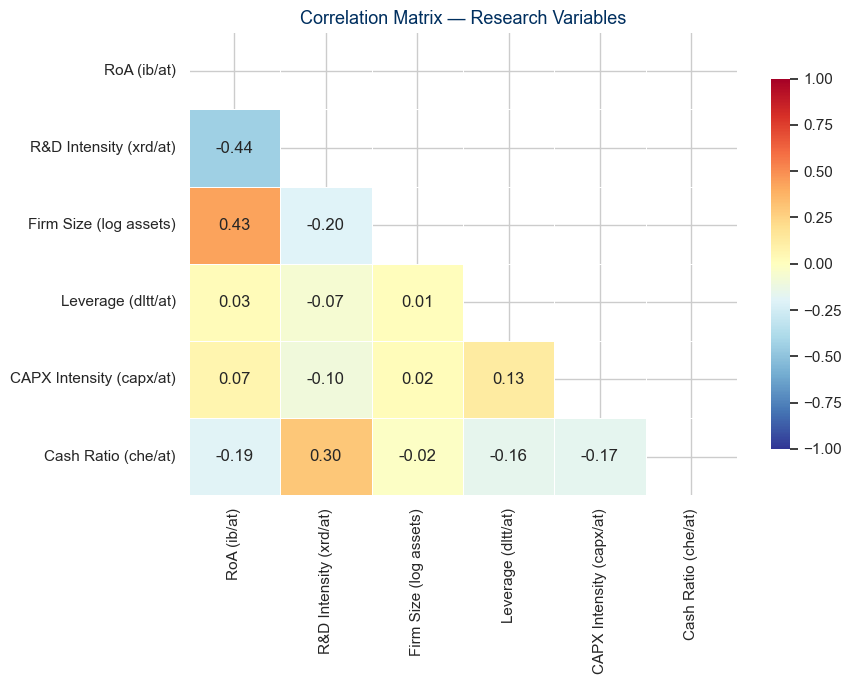

Pairs with |r| > 0.3:
  roa x rd_intensity: r = -0.44
  roa x ln_at: r = 0.43


In [8]:
corr_vars = list(VAR_LABELS.keys())
corr = df[corr_vars].rename(columns=VAR_LABELS).corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Research Variables', fontsize=13, color=WU_BLUE)
plt.tight_layout()
plt.show()

print('Pairs with |r| > 0.3:')
for i, v1 in enumerate(corr_vars):
    for v2 in corr_vars[i+1:]:
        r = corr.loc[VAR_LABELS[v1], VAR_LABELS[v2]]
        if abs(r) > 0.3:
            print(f'  {v1} x {v2}: r = {r:.2f}')

---
## Cell 9 — Main relationship: R&D intensity vs RoA

Left: scatter + bin means — shows the raw X-Y relationship  
Right: No R&D vs Has R&D firms — H2 preview  

**Note:** We split on R&D=0 vs R&D>0 instead of terciles because
median R&D = 0 — more than half the sample has zero R&D, so
terciles would produce degenerate bins.

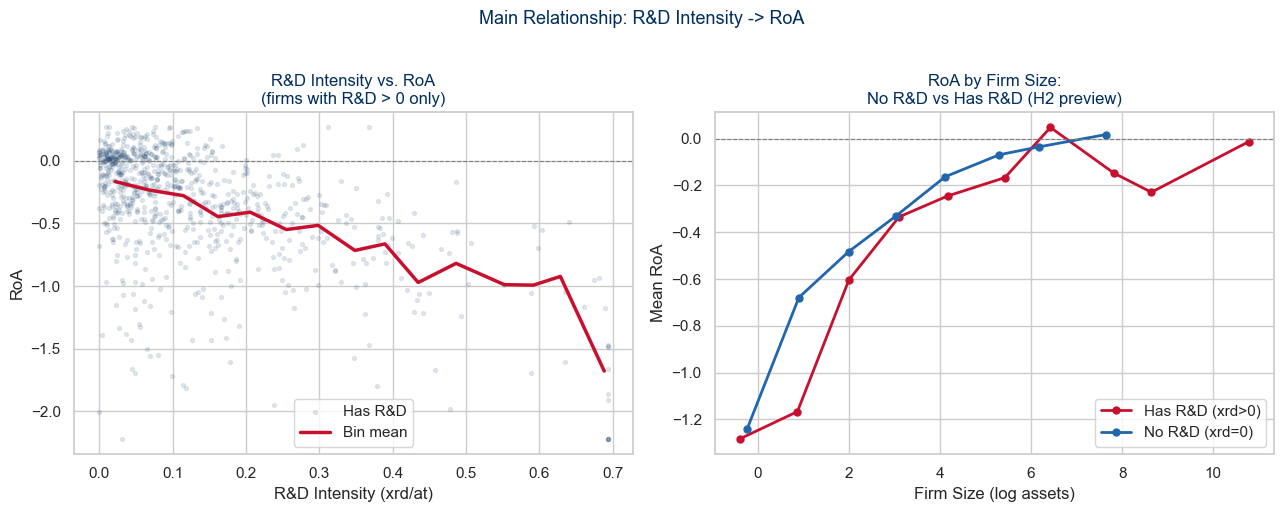

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df_plot = df.reset_index(drop=True)

# Left: scatter + bin means for R&D firms only (zero-R&D would dominate)
df_rd = df_plot[df_plot['rd_intensity'] > 0].reset_index(drop=True)
axes[0].scatter(df_rd['rd_intensity'], df_rd['roa'],
                alpha=0.1, s=8, color=WU_BLUE, label='Has R&D')
bins = pd.cut(df_rd['rd_intensity'], bins=15)
bm   = df_rd.groupby(bins, observed=True)[['rd_intensity','roa']].mean()
axes[0].plot(bm['rd_intensity'], bm['roa'],
             color=WU_RED, lw=2.5, label='Bin mean')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_xlabel('R&D Intensity (xrd/at)')
axes[0].set_ylabel('RoA')
axes[0].set_title('R&D Intensity vs. RoA\n(firms with R&D > 0 only)', color=WU_BLUE)
axes[0].legend()

# Right: No R&D vs Has R&D by firm size tercile (H2 preview)
df_plot['rd_group'] = np.where(
    df_plot['rd_intensity'] == 0, 'No R&D (xrd=0)', 'Has R&D (xrd>0)'
)
# Within each group, bin by firm size and show mean RoA
df_plot['size_bin'] = pd.cut(df_plot['ln_at'], bins=10)
palette2 = {'No R&D (xrd=0)': '#2166ac', 'Has R&D (xrd>0)': WU_RED}
for label, group in df_plot.groupby('rd_group', observed=True):
    g  = group.reset_index(drop=True)
    bm = g.groupby('size_bin', observed=True)[['ln_at','roa']].mean()
    axes[1].plot(bm['ln_at'], bm['roa'], lw=2,
                 label=label, color=palette2[label],
                 marker='o', markersize=5)
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].set_xlabel('Firm Size (log assets)')
axes[1].set_ylabel('Mean RoA')
axes[1].set_title('RoA by Firm Size:\nNo R&D vs Has R&D (H2 preview)', color=WU_BLUE)
axes[1].legend()

fig.suptitle('Main Relationship: R&D Intensity -> RoA',
             fontsize=13, color=WU_BLUE, y=1.02)
fig.tight_layout()
plt.show()

---
## Cell 10 — DV distribution + mean RoA by year

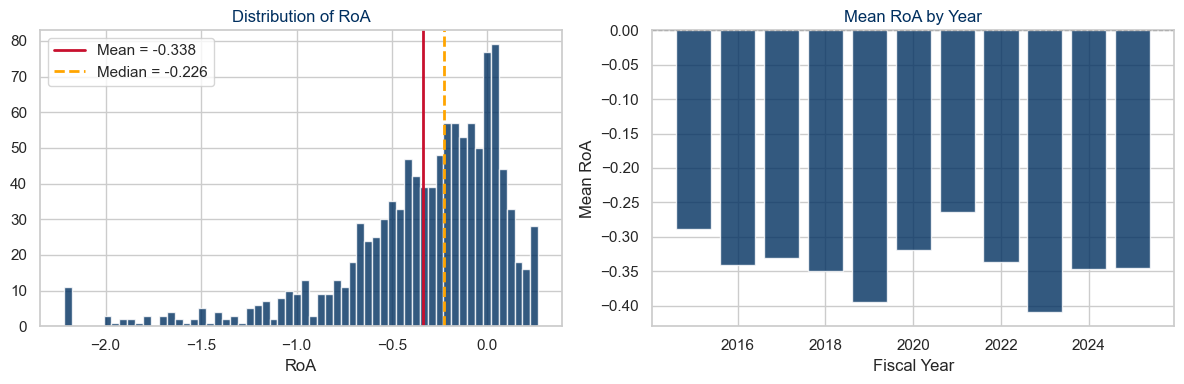

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['roa'], bins=60, color=WU_BLUE, alpha=0.8, edgecolor='white')
axes[0].axvline(df['roa'].mean(), color=WU_RED, lw=2,
                label=f'Mean = {df["roa"].mean():.3f}')
axes[0].axvline(df['roa'].median(), color='orange', lw=2, ls='--',
                label=f'Median = {df["roa"].median():.3f}')
axes[0].set_xlabel('RoA')
axes[0].set_title('Distribution of RoA', color=WU_BLUE)
axes[0].legend()

yearly = df.groupby('fyear')['roa'].mean()
axes[1].bar(yearly.index, yearly.values, color=WU_BLUE, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('Mean RoA')
axes[1].set_title('Mean RoA by Year', color=WU_BLUE)

fig.tight_layout()
plt.show()

---
## Cell 11 — Save outputs

In [11]:
from pathlib import Path
Path('output/tables').mkdir(parents=True, exist_ok=True)
Path('output/figures').mkdir(parents=True, exist_ok=True)

summary.to_csv('output/tables/summary_statistics.csv')
df.to_parquet('data/processed/panel_with_vars.parquet', index=False)

print('Saved:')
print('  output/tables/summary_statistics.csv')
print('  data/processed/panel_with_vars.parquet')
print(f'  {df.shape[0]:,} rows | {df["gvkey"].nunique():,} firms')
print(f'  R&D firms: {(df["rd_intensity"]>0).sum():,} ({(df["rd_intensity"]>0).mean()*100:.1f}%)')
print('\nNext: live_demo_regression.ipynb')

Saved:
  output/tables/summary_statistics.csv
  data/processed/panel_with_vars.parquet
  1,134 rows | 166 firms
  R&D firms: 855 (75.4%)

Next: live_demo_regression.ipynb


---
## Variable summary

| Variable | Field(s) | Formula | Role |
|----------|---------|---------|------|
| RoA | `ib`, `at` | `ib / at` | Dependent (Y) |
| R&D intensity | `xrd`, `at` | `xrd.fillna(0) / at` | Independent (X) |
| R&D × Size | — | `rd_intensity × ln_at` | H2 interaction |
| Firm size | `at` | `log(at)` | Moderator + Control |
| Leverage | `dltt`, `at` | `dltt / at` | Control |
| CAPX intensity | `capx`, `at` | `capx / at` | Control |
| Cash ratio | `che`, `at` | `che / at` | Control |

*ExInt II · WU Vienna · SS 2026 · github.com/vkiefner/sme-intl*